# Tutorial 1: Basics and first contact with Inspect AI

Welcome to the first tutorial in our AI Safety Evaluations course.

**What you'll learn:**

- Connect Inspect AI to a language model (locally via Ollama, or via cloud API)
- Run your first evaluation
- Understand how tasks are structured: dataset → solver → scorer
- View and analyze results with `inspect view`
- Create single choice and multiple choice benchmarks
- Analyzing position bias in multiple-choice tasks

**By the end:** You'll have a working evaluation pipeline and understand how to build your own benchmarks.

---
## Prerequisites: Model setup

> **💡 Inspect AI only needs a model name** — the model itself can come from anywhere.

**In this tutorial, we'll use Ollama and Perplexity, SambaNova as examples**, but you can substitute any provider: OpenAI, Anthropic, Google, local inference servers, or any OpenAI-compatible endpoint.

**Cost note:** Cloud APIs have small free tiers and then charge per token. Local models (Ollama) are completely free. For this course, a local model is sufficient for all assignments.

See [Inspect AI models docs](https://inspect.ai-safety-institute.org.uk/models.html) for the full list.

---
## Part 1: Local environment setup (Ollama)

Running evaluations locally gives you complete control and privacy.

### 1.2. Check Quotio connection

In [53]:
import os
import requests
from dotenv import load_dotenv

load_dotenv()

def check_quotio():
    """Check quotio connection and show available models."""
    base_url = "http://127.0.0.1:8317/v1"
    api_key = os.environ.get("QUOTIO_API_KEY", "")
    try:
        response = requests.get(
            f"{base_url}/models",
            headers={"Authorization": f"Bearer {api_key}"},
            timeout=5,
        )
        response.raise_for_status()
        models = response.json().get("data", [])

        print("Connected to quotio")
        print(f"Available models: {len(models)}")
        for model in models:
            print(f"  - {model['id']}")
    except requests.exceptions.ConnectionError:
        print("Cannot connect to quotio")
        print("Expected endpoint: http://127.0.0.1:8317/v1")

check_quotio()


Connected to quotio
Available models: 16
  - gpt-5
  - gpt-5-codex-mini
  - gpt-5.1-codex-mini
  - gpt-5.2
  - gpt-5.2-codex
  - gpt-5-codex
  - gpt-5.1-codex-max
  - gpt-5.4
  - gpt-5.4-mini
  - mistralai/mamba-codestral-7b-v0.1
  - qwen/qwen3.5-122b-a10b
  - gpt-5.1-codex
  - ai21labs/jamba-1.5-large-instruct
  - moonshotai/kimi-k2.5
  - gpt-5.1
  - gpt-5.3-codex


In [ ]:
# Checking connection to NVIDIA
# Base URL is https://integrate.api.nvidia.com/v1
# API key is stored in NVIDIA_API_KEY environment variable

def check_nvidia():
    """Check NVIDIA connection and show available models."""
    base_url = "https://integrate.api.nvidia.com/v1"
    api_key = os.environ.get("NVIDIA_API_KEY", "")
    try:
        response = requests.get(
            f"{base_url}/models",
            headers={"Authorization": f"Bearer {api_key}"},
            timeout=5,
        )
        response.raise_for_status()
        models = response.json().get("data", [])

        print("Connected to NVIDIA")
        print(f"Available models: {len(models)}")
        for model in models:
            print(f"  - {model['id']}")
    except requests.exceptions.ConnectionError:
        print("Cannot connect to NVIDIA")
        print("Expected endpoint: https://integrate.api.nvidia.com/v1")
        
check_nvidia()

---
## Part 2: Basic Inspect setup

### 2.1. Environment setup

Dependencies are managed with `uv` at the repository root, so we don't install packages from inside the notebook.


In [60]:
import os
from dotenv import load_dotenv

load_dotenv()

# Set for Quotio and NVIDIA if not already set

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = os.environ["QUOTIO_API_KEY"]

os.environ.setdefault("OPENAI_BASE_URL", "http://127.0.0.1:8317/v1")
MODEL = "openai/gpt-5-codex-mini"

print("Configured Inspect AI for quotio")
print(f"MODEL={MODEL}")
print(f"OPENAI_BASE_URL={os.environ['OPENAI_BASE_URL']}")
# print(f"OPENAI_BASE_URL={os.environ['NVIDIA_BASE_URL']}")


Configured Inspect AI for quotio
MODEL=openai/gpt-5-codex-mini
OPENAI_BASE_URL=http://127.0.0.1:8317/v1


### 2.2. Verify Inspect AI is available

In [ ]:
import inspect_ai, openai

print("✅ inspect-ai and openai are available in the project environment")
print(f"inspect-ai version: {inspect_ai.__version__}")


## Assignment 1: 'Hello world' in eval

Let's create the simplest possible evaluation!

**To do:** add one more `Sample()` to the dataset.

In [53]:
from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample
from inspect_ai.scorer import exact, match, model_graded_fact, choice, pattern
from inspect_ai.solver import (
    generate, system_message, chain_of_thought, 
    prompt_template, multiple_choice
)

In [54]:
@task
def hello_model():
    """Test your model setup with simple questions."""
    return Task(
        dataset=[
            Sample(
                input="Say 'Hello world!' and nothing else.",
                target="Hello world!"
            ),
            Sample(
                input="2+2=",
                target="4"
            ),
            Sample(
                input="What is the surname of Sheldon from The Big Bang Theory?",
                target="Cooper"
            ),
            
            Sample(
                input="What is the chemical symbol for water?",
                target="H2O"
            )
        ],
        solver=[generate()],
        scorer= match(
            location="end",        # where to look for the answer: "begin", "end", "any", "exact"
            ignore_case=True,      # ignore case when comparing
            numeric=False          # treat as numeric comparison (normalizes numbers, different punctuation rules)
        )
    )

**Run the evaluation:**

This will take a minute or two depending on your hardware.

In [ ]:
eval(
    hello_model,
    model=MODEL,
    model_base_url=os.environ["OPENAI_BASE_URL"],
    display="none",
    # limit=1
)

---
## Part 4: Viewing results with Inspect view

Every evaluation saves a log file. `inspect view` opens a web UI to explore them.

### 4.1. Launch Inspect view

1. In terminal, from the notebook's folder, run: `inspect view`
2. Open in browser: http://localhost:7575

This will:
1. Show all evaluation logs in an interactive interface
2. Allow you to drill down into individual samples

**Alternative options:**

```bash
# View logs from a specific directory
inspect view --log-dir ./experiment-logs

# Use a different port
inspect view --port 8080
```

**Troubleshooting:**

- If `inspect: command not found` → try `python -m inspect_ai view`
- If the page won't load → check that you're in the correct folder (logs are saved relative to where you run evaluations)

In [ ]:
# # Uncomment and run this cell if inspect view shows no logs

# import os
# from pathlib import Path

# log_files = list(Path("./logs").glob("*.eval")) if Path("./logs").exists() else []

# if not log_files:
#     print("❌ No log files found")
#     print("   Run at least one eval() in this notebook first")
#     print(f"   Current directory: {os.getcwd()}")
# else:
#     print(f"✅ Found {len(log_files)} log file(s):")
#     for f in sorted(log_files)[-5:]:  # show last 5
#         print(f"   {f.name}")

### Assignment 2: Explore your logs

In the Inspect view UI you can:

- **See overall accuracy** for each evaluation run
- **Click on individual samples** to see the model's response
- **Compare runs** with different models or parameters
- **Filter by metadata** (e.g., show only "hard" problems)
- **Export results** for further analysis

**Tip:** Keep `inspect view` running in a separate terminal while you work through this notebook. It auto-refreshes when new evaluations complete.

---
## Part 5: Understanding benchmark structure

### 5.1. Task components overview

Every Inspect `Task` consists of:

```
Task {
    dataset: [Sample, Sample, ...],    # data to evaluate on
    solver: [Solver, Solver, ...],     # how to process
    scorer: Scorer,                    # how to score
    **parameters                       
}
```

**Component flow:**
```
Dataset (Samples) → Solver(s) → Model → Scorer → Results
```

### 5.2. Sample structure

A Sample contains input/target pairs with optional metadata:

In [57]:
# Example of a fully-featured Sample
sample_example = Sample(
    input="Question or prompt",
    target="Expected answer",
    id="unique_id",
    choices=["Option A", "Option B", "Option C"],  # For multiple choice
    metadata={
        "category": "math",
        "difficulty": "hard"
    }
)

print("Sample components:")
print(f"  - input: {sample_example.input}")
print(f"  - target: {sample_example.target}")
print(f"  - choices: {sample_example.choices}")
print(f"  - metadata: {sample_example.metadata}")

Sample components:
  - input: Question or prompt
  - target: Expected answer
  - choices: ['Option A', 'Option B', 'Option C']
  - metadata: {'category': 'math', 'difficulty': 'hard'}


---
## Part 6: Understanding solvers

### 6.1. What is a solver?

A **solver** is a function that transforms a **TaskState** (the prompt + conversation history) and optionally calls the model to generate a response.

**Think of solvers as middleware that:**
1. Modifies the prompt (prompt engineering)
2. Calls the model (generation)
3. Processes the response (extraction, critique, etc.)

### 6.2. The solver pipeline

Solvers are chained together in a pipeline:

```
Input Sample
    ↓
[Solver 1: system_message]
    ↓
[Solver 2: prompt_template]
    ↓
[Solver 3: chain_of_thought]
    ↓
[Solver 4: generate]
    ↓
Model Output → Scorer → Final Result
```

Each solver receives the TaskState, modifies it, and passes it to the next solver.

### 6.3. TaskState - the core data structure

Every solver operates on a **TaskState** containing:

```
TaskState {
    messages: list[ChatMessage],  # Conversation history
    output: ModelOutput,          # Final model output
    user_prompt: str,             # Current user prompt
    input_text: str,              # Original input
    metadata: dict,               # Sample metadata
    choices: list[str],           # For multiple choice
    model: ModelName,             # Current model
    sample_id: int | str,         # Sample identifier
}
```

---
## Part 7: Built-in solvers

**system_message**
```python
system_message(
    message: str        # REQUIRED - the system prompt
)
```

**prompt_template**
```python
prompt_template(
    template: str       # REQUIRED - use {prompt} as placeholder
)
```

**chain_of_thought**
```python
chain_of_thought(
    template: str = None   # optional - custom CoT prompt (default: "Let's think step by step")
)
```

**generate**
```python
generate(
    max_tokens: int = None,      # optional - limit response length
    temperature: float = None,   # optional - 0.0 = deterministic, 1.0 = creative
    top_p: float = None,         # optional - nucleus sampling
    stop_seqs: list[str] = None  # optional - stop generation at these strings
)
```

**multiple_choice**
```python
multiple_choice(
    cot: bool = False,              # optional - add chain-of-thought
    multiple_correct: bool = False, # optional - allow multiple answers
    shuffle: bool = False           # optional - randomize choice order
)
```

**Typical pipeline:**
```
system_message → prompt_template → chain_of_thought → generate
```

`multiple_choice()` replaces the entire chain - it handles prompting and generation internally.

**Viewing solver execution:** in `inspect view`, click any sample → messages tab shows each solver's contribution.

### 7.1 system_message()

**Purpose:** prepend a system role message to guide model behavior.

**When to use:**
- establish the model's role or persona
- set global guidelines or constraints
- define the evaluation context


In [ ]:
@task
def example_system_message():
    """
    Demonstrates system_message() solver.
    The system prompt tells the model to be concise.
    """
    return Task(
        dataset=[
            Sample(input="What is 15 * 8?", target="120"),
            Sample(input="What is 99 + 1?", target="100"),
        ],
        solver=[
            system_message("You are a calculator. Reply with only the number, nothing else."),
            generate()
        ],
        scorer=match(numeric=True),
    )

# Run and check the Messages tab in inspect view
eval(example_system_message, model=MODEL, model_base_url=os.environ["OPENAI_BASE_URL"])

### 7.2 prompt_template()

**Purpose:** substitute variables into a template to reformat prompts.

**When to use:**
- add specific output format requirements
- include examples or demonstrations
- structure prompts consistently
- add reasoning steps or breakdowns


In [ ]:
STEP_BY_STEP_TEMPLATE = '''
Solve this problem step by step:

Problem: {prompt}

Structure:
1. Understand the problem
2. Plan your approach
3. Solve it
4. Final answer format: ANSWER: <value>
'''.strip()

@task
def example_prompt_template():
    """
    Demonstrates prompt_template() solver.
    The template adds structure to the prompt.
    """
    return Task(
        dataset=[
            Sample(input="What is 25 * 4?", target="100"),
            Sample(input="What is 144 / 12?", target="12"),
        ],
        solver=[
            system_message("You are a math tutor."),
            prompt_template(STEP_BY_STEP_TEMPLATE),
            generate()
        ],
        scorer=match(numeric=True),
    )

# Run and see how the template structures the prompt
eval(example_prompt_template, model=MODEL, model_base_url=os.environ["OPENAI_BASE_URL"])

### 7.3 chain_of_thought()

**Purpose:** ask the model to "think step by step" before answering.

**When to use:**
- math and logic problems
- multi-step reasoning tasks
- when you want to see the model's thought process

In [ ]:
@task
def example_chain_of_thought():
    """
    Demonstrates chain_of_thought() solver.
    Compare accuracy with and without CoT in inspect view.
    """
    return Task(
        dataset=[
            Sample(
                input="If Alice has 3 apples and Bob gives her 2 more, how many does she have?",
                target="5"
            ),
            Sample(
                input="A train travels 100 km in 2 hours. At this rate, how far in 5 hours?",
                target="250"
            ),
        ],
        solver=[
            system_message("Solve the problem. End with: ANSWER: <number>"),
            chain_of_thought(),
            generate()
        ],
        scorer=match(numeric=True),
    )

eval(example_chain_of_thought, model=MODEL, model_base_url=os.environ["OPENAI_BASE_URL"])

### 7.5. multiple_choice()

Special solver for A/B/C/D questions. Handles formatting and answer extraction automatically.

**When to use:**
- multiple choice questions (use instead of generate)
- must have letter target: "A", "B", "C", etc.

**Note:** When using `multiple_choice()`, use `choice()` as the scorer.

In [ ]:
@task
def example_multiple_choice_with_cot():
    """
    Demonstrates multiple_choice(cot=True).
    Model reasons before selecting an answer.
    """
    return Task(
        dataset=[
            Sample(
                input="Light travels faster than sound. If you see lightning and hear thunder 3 seconds later, approximately how far away was the strike?",
                choices=["100 meters", "1 kilometer", "3 kilometers", "10 kilometers"],
                target="B"  # ~1 km (sound travels ~340 m/s)
            ),
        ],
        solver=multiple_choice(cot=True),
        scorer=choice(),
    )

eval(example_multiple_choice_with_cot, model=MODEL, model_base_url=os.environ["OPENAI_BASE_URL"])

### 7.6 Other solvers

**self_critique()** - Have model refine its own answer
```python
solver=[generate(), self_critique()]
```

**use_tools()** - Enable tool/function calling
```python
solver=[use_tools(calculator()), generate()]
```

---
## Part 8: Single choice tasks

Single choice tasks present the model with limited options to select from.

### 8.1. Simple yes/no classification

The simplest single choice - binary classification:

In [ ]:
@task
def yes_no_classification():
    return Task(
        dataset=[
            Sample(
                input="Is Python a programming language?",
                target="Yes"
            ),
            Sample(
                input="Is water dry?",
                target="No"
            ),
            Sample(
                input="Is the Earth round?",
                target="Yes"
            ),
        ],
        solver=[
            system_message("Answer 'Yes' or 'No'. Be concise."),
            generate()
        ],
        scorer=exact(),
    )

eval(
    yes_no_classification,
    model=MODEL,
)

### 8.2. Multi-class classification

In multi-class classification, the model must choose from 3+ categories. This is common for:
- sentiment analysis (positive / negative / neutral)
- topic classification (sports / politics / tech / ...)
- intent detection (question / command / statement)

---

### Task 2: Build a sentiment classifier

**Your goal:** Create a sentiment classification task with at least 4 samples.

**Note:**
- `system_message` defines the classes and output format
- `target` must exactly match one of your class labels

In [ ]:
@task
def sentiment_classification():
    return Task(
        dataset = [
            Sample(input="I love this product!", target="Positive"),
            Sample(input="This is the worst experience ever.", target="Negative"),
            Sample(input="It's okay, not great but not bad.", target="Neutral"),
            Sample(input="I am extremely happy with the service.", target="Positive"),
            Sample(input="The food was terrible and the staff was rude.", target="Negative"),
            Sample(input="The movie was boring and the acting was poor.", target="Negative"),
            Sample(input="I'm not sure if it was awesome or great.", target="Neutral"),
            Sample(input="Wouldn't recommend putting this book down, ever.", target="Positive"),
        ],
        solver = [
            chain_of_thought(),
            prompt_template('''
        Classify the sentiment of the following review as Positive, Negative, or Neutral.
        Review: {prompt}
        Answer format: SENTIMENT: <Positive/Negative/Neutral>
        '''),
            generate()
        ],
        scorer = pattern(r"SENTIMENT:\s*(Positive|Negative|Neutral)"),
        )      


eval(
    sentiment_classification,
    model=MODEL,
    model_base_url=os.environ["OPENAI_BASE_URL"]
)

### 8.3. Single choice with explanation

Collect both choice and reasoning:

In [ ]:
@task
def choice_with_reasoning():
    PROMPT = '''
Classify as True or False:

Statement: {prompt}

Provide:
1. REASONING: [Your explanation]
2. ANSWER: [True or False]
    '''.strip()

    return Task(
        dataset=[
            Sample(
                input="The Earth is flat.",
                target="False"
            ),
            Sample(
                input="Water boils at 100°C at sea level.",
                target="True"
            ),
            Sample(
                input="The Great Wall of China is visible from space.",
                target="False"
            ),
        ],
        solver=[
            chain_of_thought(),
            prompt_template(PROMPT),
            generate()
        ],
        scorer=pattern(r'ANSWER:\s*(True|False)'),
    )

eval(choice_with_reasoning, model=MODEL, model_base_url=os.environ["OPENAI_BASE_URL"])

---
## Part 9: Multiple choice tasks

### 9.1. Understanding multiple choice in Inspect

Key rules:
- `choices`: list of answer options (no letters — they're added automatically)
- `target`: letter of correct answer ("A", "B", "C", or "D")
- Use `multiple_choice()` solver + `choice()` scorer

### 9.2. Multiple choice with metadata

Metadata lets you filter and analyze results in `inspect view`.

In [ ]:
@task
def mc_with_metadata():
    return Task(
        dataset=[
            Sample(
                input="Capital of Japan?",
                choices=["Seoul", "Tokyo", "Bangkok", "Beijing"],
                target="B",
                metadata={
                    "difficulty": "easy",
                    "category": "geography"
                }
            ),
            Sample(
                input="What is the Heisenberg Uncertainty Principle?",
                choices=[
                    "Cannot know both position and momentum precisely",
                    "Energy cannot be created or destroyed",
                    "All matter has wave-particle duality",
                    "Time always moves forward"
                ],
                target="A",
                metadata={
                    "difficulty": "hard",
                    "category": "physics"
                }
            ),
        ],
        solver=multiple_choice(),
        scorer=choice(),
    )

# Run and check results in inspect view - filter by metadata!
eval(mc_with_metadata, model=MODEL)

### 9.6. Multiple correct Answers

When multiple answers are valid:

In [ ]:
@task
def mc_multiple_correct():
    return Task(
        dataset=[
            Sample(
                input="Which are programming languages?",
                choices=["Python", "HTML", "JavaScript", "CSS"],
                target=["A", "C"]  # Python, JavaScript
            ),
            Sample(
                input="Which continents border the Atlantic Ocean?",
                choices=["Africa", "Asia", "Europe", "South America"],
                target=["A", "C", "D"]  # Africa, Europe, South America
            ),
        ],
        solver=[
            system_message("Select ALL correct answers. You may choose multiple options."),
            multiple_choice(multiple_correct=True)
        ],
        scorer=choice(),
    )

eval(mc_multiple_correct, model=MODEL)

---
## Part 10: Composing solvers together

## Quick reference

| Task type | Solvers | Scorer |
|-----------|---------|--------|
| Simple Q&A | `system_message() + generate()` | `match()` |
| Reasoning | `chain_of_thought() + generate()` | `match()` |
| Structured output | `prompt_template() + generate()` | `pattern()` |
| Classification | `system_message() + generate()` | `exact()` |
| Multiple choice | `multiple_choice()` | `choice()` |
| MC + reasoning | `multiple_choice(cot=True)` | `choice()` |

---
## Assignment 3: Analyzing position bias in multiple choice

Language models can develop **position bias** - a tendency to favor certain answer positions (like more often picking "A" or "C") regardless of content.

In this assignment, you will:
1. Generate a set of simple math questions in multiple-choice format
2. Create two versions of the dataset:
   - **Fixed-position:** correct answer is always in one answer slot
   - **Randomized:** correct answer position is shuffled per question
3. Run evaluations on both and compare results
4. Analyze whether the model shows position bias

⚠️ **Note on methodology:** this is a minimal experiment to get you started. Comparing a fixed-position dataset vs a randomized dataset is a quick sanity check, but it's not the most rigorous way to measure position bias.

Feel free to extend the assignment if you want a deeper analysis!

In [ ]:
import random
from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample
from inspect_ai.scorer import choice
from inspect_ai.solver import multiple_choice, system_message

# For reproducibility
random.seed(42)

### Step 1: Generate questions

First, create a helper function that generates simple questions with known correct answers.

**Function spec:**
- Input: `n` (number of problems to generate)
- Output: list of tuples `(question_text, correct_answer)`
- Example output: `[("What is 5 + 3?", "8"), ("What is 12 - 4?", "8"), ...]`

**This is just an example.** You can implement your own generator with different content - trivia, vocabulary, geography, etc. Just make sure the model can reasonably answer them.

In [46]:
def generate_questions(n: int) -> list[tuple[str, int]]:
    """
    Generate n simple math problems.
    
    Args:
        n: number of problems to generate
        
    Returns:
        List of (question_text, correct_answer) tuples
    """
    problems = []
    
    for _ in range(n):
        # Generate a list of (question_text, correct_answer) tuples
        first_num = random.randint(1, 200_000_000*n)
        second_num = random.randint(1, 200_000_000)
        operation = random.choice(['+', '-'])
        question = f"Calculate: {first_num} {operation} {second_num}"
        answer = first_num + second_num if operation == '+' else first_num - second_num
        # one liner answer with if inside
        answer = str(answer)  # Convert to string for consistency with Sample target
        problems.append((question, answer))
        # Generate a simple addition or subtraction problem
        # Hint: use random.randint() for numbers, random.choice() for operation
        pass
    
    return problems


# ===== TESTS =====
test_questions = generate_questions(5)

assert len(test_questions) == 5, f"Expected 5 questions, got {len(test_questions)}"
assert all(isinstance(q, tuple) and len(q) == 2 for q in test_questions), "Each question must be a tuple of (question_text, answer)"
assert all(isinstance(q[0], str) and isinstance(q[1], str) for q in test_questions), "Both question and answer must be strings"
assert all(len(q[0]) > 0 and len(q[1]) > 0 for q in test_questions), "Question and answer cannot be empty"

print("\nSample output:")
for q, a in test_questions:
    print(f"  {q} → {a}")


Sample output:
  Calculate: 670355807 - 169940240 → 500415567
  Calculate: 408992978 - 160361155 → 248631823
  Calculate: 487173221 - 135707834 → 351465387
  Calculate: 106492060 + 188382479 → 294874539
  Calculate: 915679228 + 175748172 → 1091427400


### Step 2: Create wrong answers (distractors)

For multiple choice, we need plausible wrong answers.

**Function spec:**
- Input: `correct_answer` (int)
- Output: list of 3 wrong answers (ints), all different from correct and from each other

**Tip:** generate distractors close to the correct answer (e.g., ±1, ±2, ±10) to make them plausible.

In [49]:
def generate_distractors(correct: str, n: int = 3) -> list[str]:
    """
    Generate n plausible wrong answers.
    
    For numeric answers: generates nearby numbers.
    For other types: you'll need to customize this.
    
    Args:
        correct: the correct answer (string)
        n: number of distractors to generate
        
    Returns:
        List of n distinct wrong answers (strings)
    """
    distractors = set()

    offsets = [-10, -3, -2, -1, 1, 2, 3, 10]


    while len(distractors) < n:
        # Generate offsets and find wrong answers that are close to correct but not equal
        offset = random.choice(offsets)
        wrong_answer = str(int(correct) + offset)
        if wrong_answer != correct:
            distractors.add(wrong_answer)

    return list(distractors)

# ===== TESTS =====
test_distractors = generate_distractors("10", n=3)

assert len(test_distractors) == 3, f"Expected 3 distractors, got {len(test_distractors)}"
assert all(isinstance(d, str) for d in test_distractors), "All distractors must be strings"
assert "10" not in test_distractors, "Distractors must not include the correct answer"
assert len(set(test_distractors)) == 3, "All distractors must be unique"

print(f"   Distractors for '10': {test_distractors}")

   Distractors for '10': ['13', '12', '7']


### Step 3: Create multiple choice samples

Now create a function that converts questions into multiple-choice format.

**Function spec:**
- Input: 
  - `questions` - list of `(question_text, correct_answer)` tuples
  - `correct_position` - where to place correct answer:
    - `None` → randomize position for each question
    - `0` → always position A
    - `1` → always position B
    - `2` → always position C
    - `3` → always position D
- Output:
    - list of `Sample` objects

⚠️ **Note on `Sample` type:**

`Sample` is an Inspect AI class. For multiple choice, you create it like this:
```python
Sample(
    input="What is 2 + 2?",           # question text
    choices=["3", "4", "5", "6"],     # list of options: list[str]
    target="B"                         # letter of correct answer (A/B/C/D)
)
```

In [50]:
def create_samples(
    questions: list[tuple[str, str]], 
    correct_position: int | None = None
) -> list[Sample]:
    """
    Convert questions to multiple-choice Samples.
    
    Args:
        questions: list of (question_text, correct_answer) tuples
        correct_position: 
            None → randomize position (A/B/C/D) for each question
            0 → correct answer always at position A
            1 → correct answer always at position B
            2 → correct answer always at position C  
            3 → correct answer always at position D
            
    Returns:
        List of Sample objects ready for Inspect AI.
        Each Sample has:
            - input: str (the question)
            - choices: list[str] (4 options, no letters)
            - target: str (correct letter: "A", "B", "C", or "D")
    """
    samples = []
    
    for question, correct in questions:       
        # 1. Generate 3 distractors (use generate_distractors() function)
        # 2. Build list of 4 options
        # 3. Place correct answer at the right position:
        #    - If correct_position is None → put all options together and shuffle
        #    - Otherwise → put correct at that index
        # 4. Determine target letter based on where correct ended up
        # 5. Create Sample(input=..., choices=..., target=...)
        generated_distractors = generate_distractors(correct, n=3)
        options = generated_distractors + [correct]
        if correct_position is not None:
            # Place correct answer at specified position
            options.remove(correct)
            options.insert(correct_position, correct)
            target_letter = "ABCD"[correct_position]
        else:
            # Randomize positions
            random.shuffle(options)
            target_letter = "ABCD"[options.index(correct)]
        # determine target letter based on where correct ended up
        sample = Sample(
            input=question,
            choices=options,
            target=target_letter
        )
        samples.append(sample)
    
    return samples


# ===== TESTS =====
test_q = [("What is 2 + 2?", "4"), ("What is 10 - 3?", "7"), ("What is 5 + 5?", "10")]
samples_fixed = create_samples(test_q, correct_position=0)
samples_random = create_samples(test_q, correct_position=None)

assert len(samples_fixed) == len(test_q), f"Expected {len(test_q)} samples, got {len(samples_fixed)}"
assert all(hasattr(s, 'input') and hasattr(s, 'choices') and hasattr(s, 'target') for s in samples_fixed), "Each sample must have 'input', 'choices', and 'target' attributes"
assert all(len(s.choices) == 4 for s in samples_fixed), "Each sample must have exactly 4 choices"
assert all(s.target == "A" for s in samples_fixed), "With correct_position=0, all targets should be 'A'"
assert all(s.choices[0] == correct for s, (_, correct) in zip(samples_fixed, test_q)), "With correct_position=0, correct answer should be first in choices"
assert all(s.target in "ABCD" for s in samples_random), "Target must be one of A, B, C, D"

# Check that correct answer is actually at the target position
for s, (_, correct) in zip(samples_random, test_q):
    target_index = "ABCD".index(s.target)
    assert s.choices[target_index] == correct, f"Correct answer '{correct}' should be at position {s.target}, but found '{s.choices[target_index]}'"


### Step 4: Create the tasks

Now wrap your datasets into Inspect Tasks.

**Already provided:** task structure. You just need to call your functions.

In [51]:
@task
def position_bias_task(
    questions: list[tuple[str, int]],
    correct_position: int | None = None
):
    """
    Multiple choice evaluation task.
    
    Args:
        questions: list of (question_text, correct_answer) tuples
        correct_position: None for random, 0-3 for fixed position
    """
    samples = create_samples(questions, correct_position)

    return Task(
        dataset=samples,
        solver = multiple_choice(),
        scorer = choice()
    )
    
# CoT version - you can compare results in inspect view
@task
def position_bias_task_cot(
    questions: list[tuple[str, int]],
    correct_position: int | None = None
):
    """ Multiple choice evaluation task with chain of thought reasoning.

    Args:
        questions (list[tuple[str, int]]): List of (question_text, correct_answer) tuples
        correct_position (int | None, optional): Position of the correct answer. Defaults to None.

    Returns:
        _type_: Task object with multiple choice solver using chain of thought reasoning.
    """
    samples = create_samples(questions, correct_position)
    return Task(
        dataset=samples,
        solver = multiple_choice(cot=True),
        scorer = choice()
    )
    


### Step 5: Generate questions and run evaluations

Generate questions once, then run two evaluations:
1. **Fixed-position:** correct answer always at one chosen position
2. **Randomized:** correct answer position randomized

In [6]:
from pathlib import Path

from inspect_ai.log import list_eval_logs, read_eval_log


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "w1").exists():
            return candidate
    if cwd.name == "w1" and (cwd.parent / "pyproject.toml").exists():
        return cwd.parent
    return cwd


PROJECT_ROOT = resolve_project_root()
TUTORIAL_LOG_DIR = PROJECT_ROOT / "w1" / "logs"
TUTORIAL_LOG_DIR.mkdir(parents=True, exist_ok=True)


def tutorial_log_matches(log, *, task_name: str, model_name: str, correct_position: int | None, questions: list[list[str]]) -> bool:
    if log.status != "success":
        return False
    if log.eval.task != task_name or log.eval.model != model_name:
        return False

    task_args = getattr(log.eval, "task_args", None) or {}
    return (
        task_args.get("correct_position") == correct_position
        and task_args.get("questions") == questions
    )



def reuse_or_run_tutorial_eval(task_fn, *, task_name: str, model_name: str, questions: list[list[str]], correct_position: int | None):
    for info in list_eval_logs(log_dir=str(TUTORIAL_LOG_DIR)):
        log = read_eval_log(info, header_only=True)
        if tutorial_log_matches(
            log,
            task_name=task_name,
            model_name=model_name,
            correct_position=correct_position,
            questions=questions,
        ):
            print(f"Reusing {task_name} correct_position={correct_position} from {info.name}")
            return read_eval_log(info)

    print(f"Running {task_name} correct_position={correct_position}")
    return eval(
        task_fn,
        model=model_name,
        task_args={"questions": questions, "correct_position": correct_position},
        log_dir=str(TUTORIAL_LOG_DIR),
        display="none",
    )[0]


N_QUESTIONS = 50

random.seed(42)
questions = generate_questions(N_QUESTIONS)
question_rows = [[question, answer] for question, answer in questions]

tutorial_eval_logs = [
    reuse_or_run_tutorial_eval(
        position_bias_task,
        task_name="position_bias_task",
        model_name=MODEL,
        questions=question_rows,
        correct_position=3,
    ),
    reuse_or_run_tutorial_eval(
        position_bias_task,
        task_name="position_bias_task",
        model_name=MODEL,
        questions=question_rows,
        correct_position=None,
    ),
    reuse_or_run_tutorial_eval(
        position_bias_task_cot,
        task_name="position_bias_task_cot",
        model_name=MODEL,
        questions=question_rows,
        correct_position=3,
    ),
    reuse_or_run_tutorial_eval(
        position_bias_task_cot,
        task_name="position_bias_task_cot",
        model_name=MODEL,
        questions=question_rows,
        correct_position=None,
    ),
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded {len(tutorial_eval_logs)} tutorial eval log(s) from {TUTORIAL_LOG_DIR}")

NameError: name 'random' is not defined

### Step 7: Analyze your results

The small tutorial runs above are still useful as a sanity check, but the stronger result comes from the cached position-bias benchmark logs in `w1/position_bias_exploration_logs`.

The cells below:
- reuse the latest successful cached run for every available model/condition pair instead of rerunning matching evals
- include partial Qwen coverage where it exists and explicitly report the missing conditions
- flag older duplicate logs so you can clean the directory safely
- summarize accuracy and answer-position sensitivity
- render the charts inline and save PNG copies to `w1/position_bias_outputs/`

### Cached position-bias analysis

In [7]:
import math
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from inspect_ai.log import list_eval_logs, read_eval_log, read_eval_log_sample_summaries

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "w1").exists():
            return candidate
    if cwd.name == "w1" and (cwd.parent / "pyproject.toml").exists():
        return cwd.parent
    return cwd


PROJECT_ROOT = resolve_project_root()
POSITION_BIAS_LOG_DIR = PROJECT_ROOT / "w1" / "position_bias_exploration_logs"
POSITION_BIAS_OUTPUT_DIR = PROJECT_ROOT / "w1" / "position_bias_outputs"
POSITION_BIAS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_POSITION_BIAS_CONDITIONS = {
    4: ["randomized", "fixed_A", "fixed_B", "fixed_C", "fixed_D"],
    6: ["randomized", "fixed_A", "fixed_B", "fixed_C", "fixed_D", "fixed_E", "fixed_F"],
}


def answer_letters(option_count: int) -> list[str]:
    return list("ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:option_count])



def fixed_position_label(position: int | None, option_count: int) -> str:
    if position is None:
        return "randomized"
    return f"fixed_{answer_letters(option_count)[position]}"



def extract_predicted_letter(score, option_count: int) -> str | None:
    labels = set(answer_letters(option_count))
    answer = getattr(score, "answer", None)
    if isinstance(answer, str):
        cleaned = answer.strip().replace("$", "")
        if cleaned in labels:
            return cleaned

    explanation = getattr(score, "explanation", "") or ""
    match = re.search(r"ANSWER:\s*\$?([A-Z])", explanation)
    if match and match.group(1) in labels:
        return match.group(1)

    return None



def cached_position_bias_index(log_dir: Path, n_questions: int = 28):
    latest_by_model: dict[str, dict[tuple[int, str], object]] = {}
    redundant_logs: list[str] = []

    for info in list_eval_logs(log_dir=str(log_dir)):
        log = read_eval_log(info, header_only=True)
        metadata = log.eval.metadata or {}

        if log.status != "success":
            continue
        if metadata.get("benchmark") != "position_bias_exploration":
            continue
        if int(metadata.get("n_questions", -1)) != n_questions:
            continue

        model_label = metadata["model_label"]
        option_count = int(metadata["option_count"])
        condition_label = metadata["condition_label"]
        key = (option_count, condition_label)

        latest_for_model = latest_by_model.setdefault(model_label, {})
        if key in latest_for_model:
            redundant_logs.append(info.name)
            continue

        latest_for_model[key] = info

    model_coverage_rows = []
    complete_models = []
    for model_label, log_index in sorted(latest_by_model.items()):
        missing = [
            (option_count, condition_label)
            for option_count, conditions in EXPECTED_POSITION_BIAS_CONDITIONS.items()
            for condition_label in conditions
            if (option_count, condition_label) not in log_index
        ]
        if not missing:
            complete_models.append(model_label)
        model_coverage_rows.append(
            {
                "model_label": model_label,
                "available_conditions": len(log_index),
                "expected_conditions": sum(len(v) for v in EXPECTED_POSITION_BIAS_CONDITIONS.values()),
                "is_complete": not missing,
                "missing_conditions": ", ".join(f"{option_count}:{condition_label}" for option_count, condition_label in missing),
            }
        )

    return latest_by_model, pd.DataFrame(model_coverage_rows), redundant_logs, complete_models



def build_position_bias_sample_frame(log_index_by_model: dict[str, dict[tuple[int, str], object]]) -> pd.DataFrame:
    rows: list[dict] = []

    for model_label, log_index in sorted(log_index_by_model.items()):
        for (option_count, condition_label), info in sorted(log_index.items()):
            log = read_eval_log(info, header_only=True)
            metadata = log.eval.metadata or {}

            for sample in read_eval_log_sample_summaries(info):
                score = next(iter(sample.scores.values()))
                rows.append(
                    {
                        "model_label": model_label,
                        "model_name": metadata["model_name"],
                        "option_count": option_count,
                        "condition_label": condition_label,
                        "correct_position": metadata["correct_position"],
                        "fixed_position_label": fixed_position_label(metadata["correct_position"], option_count),
                        "sample_id": sample.id,
                        "input": sample.input,
                        "target": sample.target,
                        "predicted": extract_predicted_letter(score, option_count),
                        "correct": score.value == "C",
                        "kind": (sample.metadata or {}).get("kind"),
                        "working_time": sample.working_time,
                        "log_path": info.name,
                    }
                )

    return pd.DataFrame(rows)


position_bias_log_index, position_bias_coverage_df, redundant_position_bias_logs, complete_position_bias_models = cached_position_bias_index(
    POSITION_BIAS_LOG_DIR
)

if not position_bias_log_index:
    raise FileNotFoundError(f"No cached position-bias benchmark logs were found in {POSITION_BIAS_LOG_DIR}.")

position_bias_sample_df = build_position_bias_sample_frame(position_bias_log_index)
loaded_models = sorted(position_bias_log_index)
print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded {len(position_bias_sample_df)} benchmark samples from cached models: {', '.join(loaded_models)}")
print(f"Redundant older logs available for cleanup: {len(redundant_position_bias_logs)}")
if redundant_position_bias_logs:
    display(pd.DataFrame({"redundant_log": redundant_position_bias_logs[:10]}))

print("Model coverage")
display(position_bias_coverage_df)
print(f"Complete model matrices: {', '.join(complete_position_bias_models) if complete_position_bias_models else 'none'}")

Project root: /Users/zakhar/Desktop/code/monoid
Loaded 616 benchmark samples from cached models: gpt-5-codex-mini, qwen3.5-122b-a10b
Redundant older logs available for cleanup: 30


,redundant_log
0,file:///Users/zakhar/Desktop/code/monoid/w1/po...
1,file:///Users/zakhar/Desktop/code/monoid/w1/po...
2,file:///Users/zakhar/Desktop/code/monoid/w1/po...
3,file:///Users/zakhar/Desktop/code/monoid/w1/po...
4,file:///Users/zakhar/Desktop/code/monoid/w1/po...
5,file:///Users/zakhar/Desktop/code/monoid/w1/po...
6,file:///Users/zakhar/Desktop/code/monoid/w1/po...
7,file:///Users/zakhar/Desktop/code/monoid/w1/po...
8,file:///Users/zakhar/Desktop/code/monoid/w1/po...
9,file:///Users/zakhar/Desktop/code/monoid/w1/po...


Model coverage


,model_label,available_conditions,expected_conditions,is_complete,missing_conditions
0,gpt-5-codex-mini,12,12,True,
1,qwen3.5-122b-a10b,10,12,False,"6:fixed_C, 6:fixed_D"


Complete model matrices: gpt-5-codex-mini


In [8]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def wilson_interval(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return (float("nan"), float("nan"))
    phat = successes / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    margin = z * math.sqrt((phat * (1 - phat) + z**2 / (4 * n)) / n) / denom
    return (center - margin, center + margin)



def monte_carlo_uniform_pvalue(counts: list[int], simulations: int = 5_000, seed: int = 42) -> tuple[float, float]:
    observed = np.array(counts, dtype=float)
    n = int(observed.sum())
    k = len(observed)
    if n == 0 or k <= 1:
        return (float("nan"), float("nan"))

    expected = n / k
    chi2 = float(((observed - expected) ** 2 / expected).sum())
    rng = np.random.default_rng(seed)
    sims = rng.multinomial(n, [1 / k] * k, size=simulations)
    sim_stats = ((sims - expected) ** 2 / expected).sum(axis=1)
    p_value = float((np.count_nonzero(sim_stats >= chi2) + 1) / (simulations + 1))
    return chi2, p_value



def summarize_position_bias_runs(sample_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    group_cols = ["model_label", "option_count", "condition_label", "correct_position", "fixed_position_label"]
    for keys, group in sample_df.groupby(group_cols, dropna=False):
        model_label, option_count, condition_label, correct_position, fixed_label = keys
        correct_n = int(group["correct"].sum())
        n = len(group)
        ci_low, ci_high = wilson_interval(correct_n, n)
        records.append(
            {
                "model_label": model_label,
                "option_count": option_count,
                "condition_label": condition_label,
                "correct_position": correct_position,
                "fixed_position_label": fixed_label,
                "n": n,
                "correct_n": correct_n,
                "accuracy": correct_n / n,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "avg_working_time": group["working_time"].mean(),
            }
        )
    return pd.DataFrame(records).sort_values(["model_label", "option_count", "condition_label"])



def randomized_position_stats(sample_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    randomized = sample_df[sample_df["condition_label"] == "randomized"].copy()
    for (model_label, option_count), group in randomized.groupby(["model_label", "option_count"]):
        labels = answer_letters(int(option_count))
        counts = [int((group["predicted"] == label).sum()) for label in labels]
        chi2, p_value = monte_carlo_uniform_pvalue(counts)
        n = len(group)
        cramers_v = math.sqrt(chi2 / (n * (option_count - 1))) if n and option_count > 1 else float("nan")
        row = {
            "model_label": model_label,
            "option_count": option_count,
            "n": n,
            "chi2_uniform": chi2,
            "p_value_uniform": p_value,
            "cramers_v": cramers_v,
        }
        row.update({f"count_{label}": count for label, count in zip(labels, counts)})
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["model_label", "option_count"])



def fixed_position_gaps(run_summary: pd.DataFrame) -> pd.DataFrame:
    rows = []
    fixed = run_summary[run_summary["condition_label"] != "randomized"].copy()
    for (model_label, option_count), group in fixed.groupby(["model_label", "option_count"]):
        rows.append(
            {
                "model_label": model_label,
                "option_count": option_count,
                "conditions_present": len(group),
                "min_accuracy": group["accuracy"].min(),
                "max_accuracy": group["accuracy"].max(),
                "accuracy_gap": group["accuracy"].max() - group["accuracy"].min(),
            }
        )
    return pd.DataFrame(rows).sort_values(["model_label", "option_count"])


position_bias_run_summary = summarize_position_bias_runs(position_bias_sample_df)
position_bias_randomized_stats = randomized_position_stats(position_bias_sample_df)
position_bias_fixed_gaps = fixed_position_gaps(position_bias_run_summary)

print("Run summary")
display(position_bias_run_summary)
print("\nRandomized position stats")
display(position_bias_randomized_stats)
print("\nFixed-position accuracy gaps")
display(position_bias_fixed_gaps)

for row in position_bias_fixed_gaps.itertuples(index=False):
    print(
        f"{row.model_label} with {int(row.option_count)} options: fixed-position accuracy ranged from "
        f"{row.min_accuracy:.3f} to {row.max_accuracy:.3f} (gap={row.accuracy_gap:.3f}) across {row.conditions_present} fixed conditions present"
    )

for row in position_bias_randomized_stats.itertuples(index=False):
    print(
        f"{row.model_label} with {int(row.option_count)} options: chi2={row.chi2_uniform:.2f}, "
        f"Monte Carlo p≈{row.p_value_uniform:.4f}, Cramér's V={row.cramers_v:.3f}"
    )

partial_models = position_bias_coverage_df[~position_bias_coverage_df["is_complete"]]["model_label"].tolist()
summary_lines = [
    f"- Cached models included in analysis: {', '.join(sorted(position_bias_run_summary['model_label'].unique()))}.",
    f"- Complete matrices: {', '.join(complete_position_bias_models) if complete_position_bias_models else 'none'}.",
    f"- Partial matrices: {', '.join(partial_models) if partial_models else 'none'}.",
]

display(Markdown("\n".join(summary_lines)))

Run summary


,model_label,option_count,condition_label,correct_position,fixed_position_label,n,correct_n,accuracy,ci_low,ci_high,avg_working_time
0,gpt-5-codex-mini,4,fixed_A,0.0,fixed_A,28,26,0.928571,0.773543,0.980188,1.884571
1,gpt-5-codex-mini,4,fixed_B,1.0,fixed_B,28,19,0.678571,0.493385,0.820670,2.078107
2,gpt-5-codex-mini,4,fixed_C,2.0,fixed_C,28,25,0.892857,0.728038,0.962882,2.325143
3,gpt-5-codex-mini,4,fixed_D,3.0,fixed_D,28,28,1.000000,0.879353,1.000000,1.810464
4,gpt-5-codex-mini,4,randomized,NaN,randomized,28,24,0.857143,0.685098,0.943011,2.330929
5,gpt-5-codex-mini,6,fixed_A,0.0,fixed_A,28,27,0.964286,0.822874,0.993668,2.237500
6,gpt-5-codex-mini,6,fixed_B,1.0,fixed_B,28,20,0.714286,0.529404,0.847462,2.153857
7,gpt-5-codex-mini,6,fixed_C,2.0,fixed_C,28,22,0.785714,0.604611,0.897877,2.206357
8,gpt-5-codex-mini,6,fixed_D,3.0,fixed_D,28,28,1.000000,0.879353,1.000000,2.275286
9,gpt-5-codex-mini,6,fixed_E,4.0,fixed_E,28,21,0.750000,0.566440,0.873237,3.042536



Randomized position stats


,model_label,option_count,n,chi2_uniform,p_value_uniform,cramers_v,count_A,count_B,count_C,count_D,count_E,count_F
0,gpt-5-codex-mini,4,28,0.000000,1.000000,0.000000,7,7,7,7,NaN,NaN
1,gpt-5-codex-mini,6,28,2.000000,0.887822,0.119523,3,3,6,5,6.0,5.0
2,qwen3.5-122b-a10b,4,28,0.571429,0.923815,0.082479,8,6,6,8,NaN,NaN
3,qwen3.5-122b-a10b,6,28,8.428571,0.128574,0.245365,3,2,8,8,2.0,5.0



Fixed-position accuracy gaps


,model_label,option_count,conditions_present,min_accuracy,max_accuracy,accuracy_gap
0,gpt-5-codex-mini,4,4,0.678571,1.000000,0.321429
1,gpt-5-codex-mini,6,6,0.714286,1.000000,0.285714
2,qwen3.5-122b-a10b,4,4,0.571429,0.821429,0.250000
3,qwen3.5-122b-a10b,6,4,0.714286,0.785714,0.071429


gpt-5-codex-mini with 4 options: fixed-position accuracy ranged from 0.679 to 1.000 (gap=0.321) across 4 fixed conditions present
gpt-5-codex-mini with 6 options: fixed-position accuracy ranged from 0.714 to 1.000 (gap=0.286) across 6 fixed conditions present
qwen3.5-122b-a10b with 4 options: fixed-position accuracy ranged from 0.571 to 0.821 (gap=0.250) across 4 fixed conditions present
qwen3.5-122b-a10b with 6 options: fixed-position accuracy ranged from 0.714 to 0.786 (gap=0.071) across 4 fixed conditions present
gpt-5-codex-mini with 4 options: chi2=0.00, Monte Carlo p≈1.0000, Cramér's V=0.000
gpt-5-codex-mini with 6 options: chi2=2.00, Monte Carlo p≈0.8878, Cramér's V=0.120
qwen3.5-122b-a10b with 4 options: chi2=0.57, Monte Carlo p≈0.9238, Cramér's V=0.082
qwen3.5-122b-a10b with 6 options: chi2=8.43, Monte Carlo p≈0.1286, Cramér's V=0.245


- Cached models included in analysis: gpt-5-codex-mini, qwen3.5-122b-a10b.
- Complete matrices: gpt-5-codex-mini.
- Partial matrices: qwen3.5-122b-a10b.

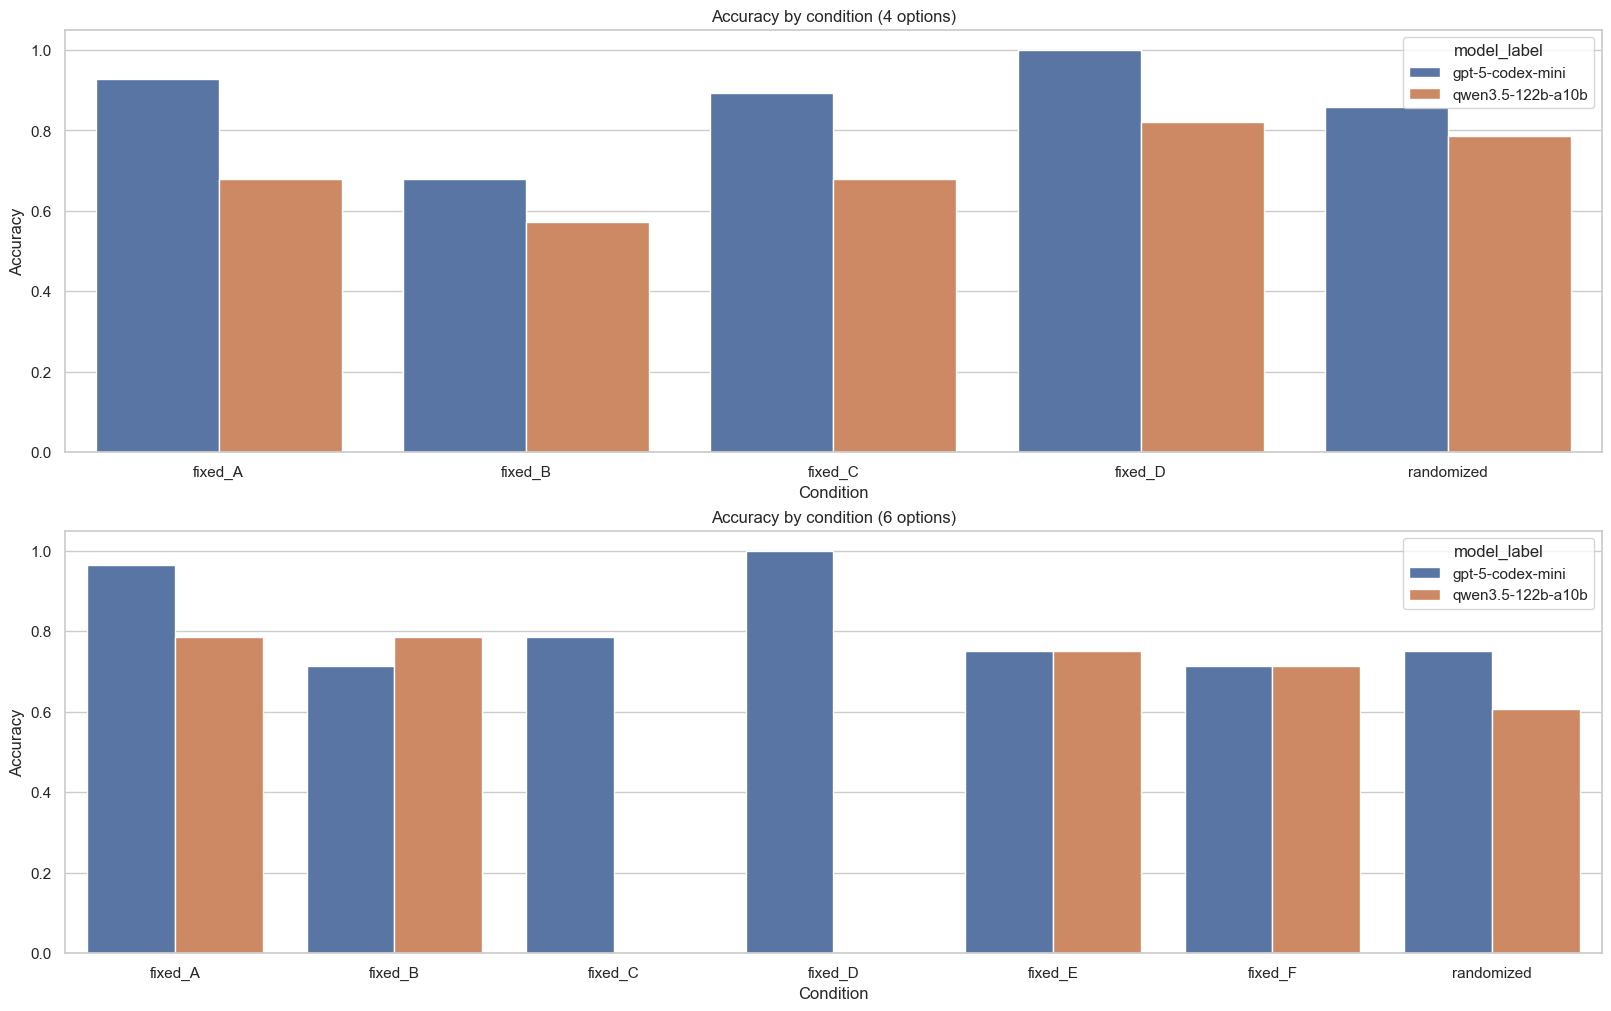

Saved /Users/zakhar/Desktop/code/monoid/w1/position_bias_outputs/main_accuracy_by_condition.png


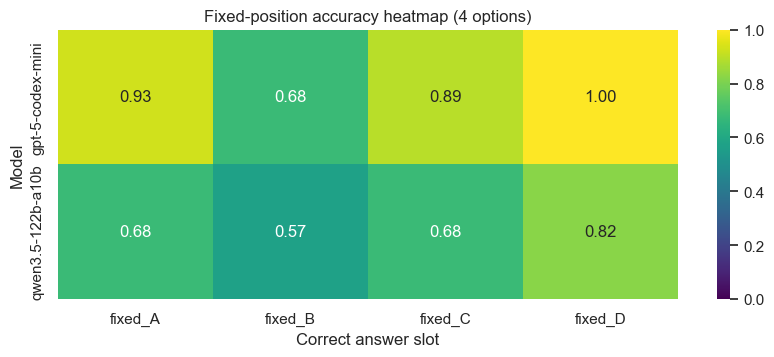

Saved /Users/zakhar/Desktop/code/monoid/w1/position_bias_outputs/main_fixed_position_heatmap_4.png


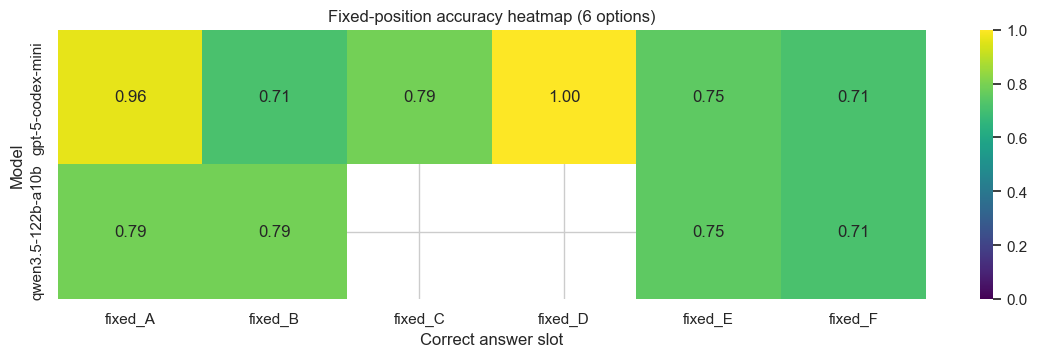

Saved /Users/zakhar/Desktop/code/monoid/w1/position_bias_outputs/main_fixed_position_heatmap_6.png


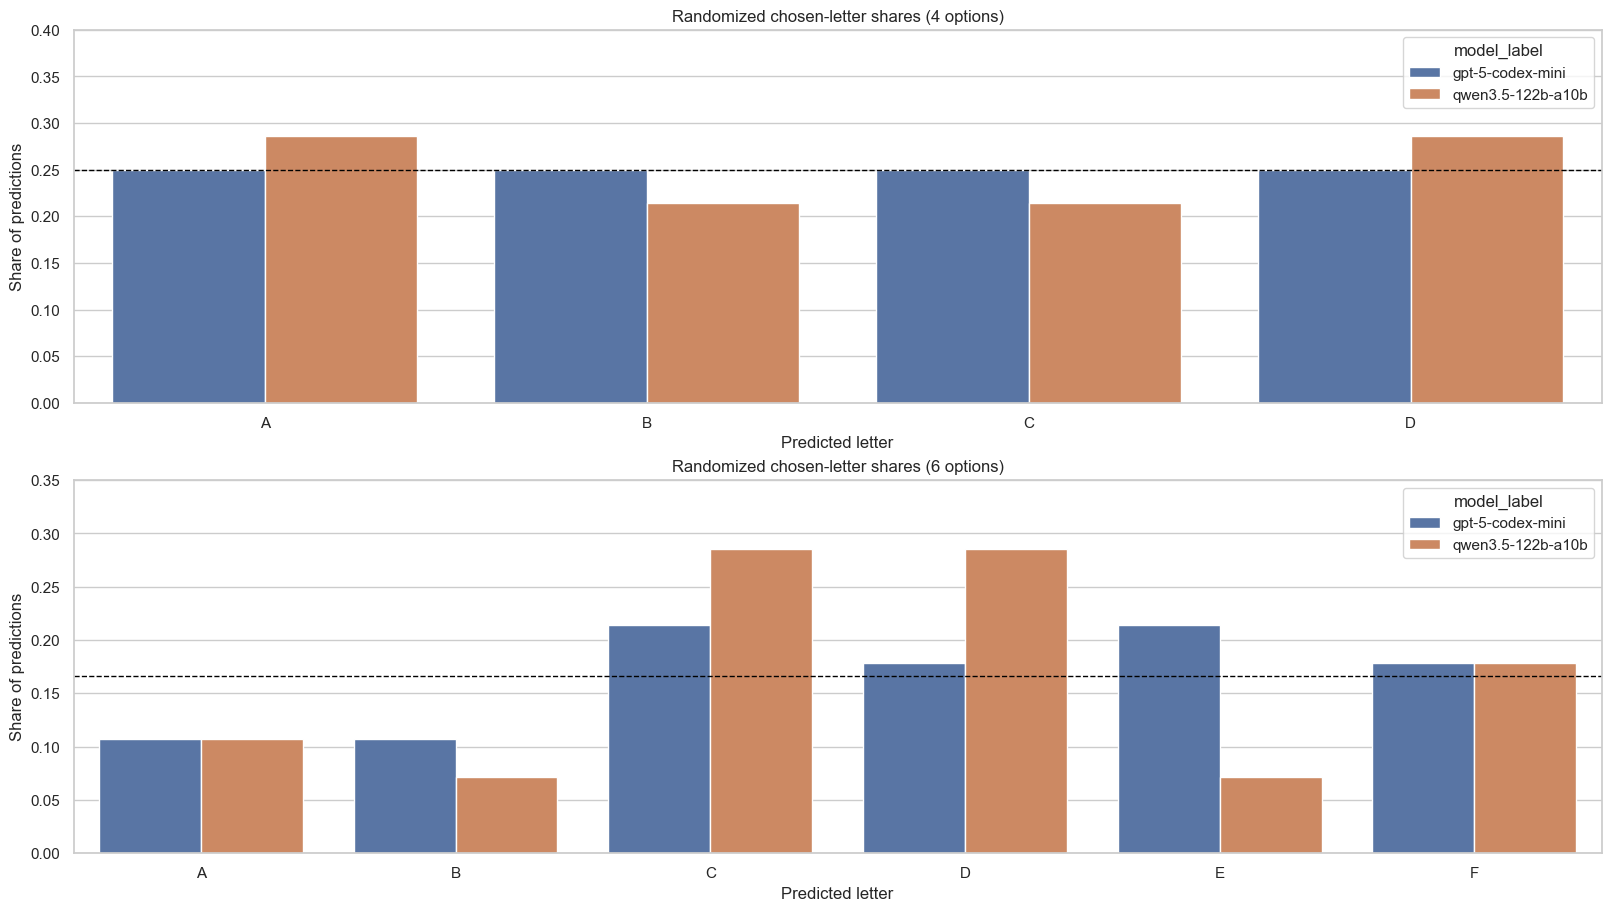

Saved /Users/zakhar/Desktop/code/monoid/w1/position_bias_outputs/main_randomized_choice_shares.png


In [9]:
plot_df = position_bias_run_summary.copy()
plot_df["condition_plot"] = plot_df["fixed_position_label"]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)
for ax, option_count in zip(axes, [4, 6]):
    subset = plot_df[plot_df["option_count"] == option_count]
    sns.barplot(data=subset, x="condition_plot", y="accuracy", hue="model_label", ax=ax)
    ax.set_title(f"Accuracy by condition ({option_count} options)")
    ax.set_xlabel("Condition")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
accuracy_path = POSITION_BIAS_OUTPUT_DIR / "main_accuracy_by_condition.png"
fig.savefig(accuracy_path, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved {accuracy_path}")

fixed_df = position_bias_run_summary[position_bias_run_summary["condition_label"] != "randomized"].copy()
for option_count in [4, 6]:
    subset = fixed_df[fixed_df["option_count"] == option_count]
    pivot = subset.pivot(index="model_label", columns="fixed_position_label", values="accuracy")
    ordered_columns = [fixed_position_label(i, option_count) for i in range(option_count)]
    pivot = pivot.reindex(columns=ordered_columns)

    fig, ax = plt.subplots(figsize=(2 + 2 * option_count, 3.5))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax)
    ax.set_title(f"Fixed-position accuracy heatmap ({option_count} options)")
    ax.set_xlabel("Correct answer slot")
    ax.set_ylabel("Model")
    path = POSITION_BIAS_OUTPUT_DIR / f"main_fixed_position_heatmap_{option_count}.png"
    fig.savefig(path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved {path}")

randomized = position_bias_sample_df[position_bias_sample_df["condition_label"] == "randomized"].copy()
choice_share = randomized.groupby(["model_label", "option_count", "predicted"]).size().rename("count").reset_index()
choice_share["share"] = choice_share.groupby(["model_label", "option_count"])["count"].transform(lambda s: s / s.sum())

fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
for ax, option_count in zip(axes, [4, 6]):
    subset = choice_share[choice_share["option_count"] == option_count]
    sns.barplot(data=subset, x="predicted", y="share", hue="model_label", ax=ax)
    ax.axhline(1 / option_count, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Randomized chosen-letter shares ({option_count} options)")
    ax.set_xlabel("Predicted letter")
    ax.set_ylabel("Share of predictions")
    ax.set_ylim(0, max(0.35, 1 / option_count + 0.15))
choice_path = POSITION_BIAS_OUTPUT_DIR / "main_randomized_choice_shares.png"
fig.savefig(choice_path, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved {choice_path}")

### Bonus challenges (optional)

If you want to explore further:

1. **Try different models** - Do all models show the same bias pattern?

2. **Add Chain-of-Thought** - Does `multiple_choice(cot=True)` reduce position bias?

3. **More positions** - What if you have 5 or 6 choices instead of 4?

4. **Statistical test** - Is the position preference statistically significant? (Chi-squared test)

5. **Content factors** - What else might affect position bias?